<div class="alert alert-info" role="alert" style="padding:20px; margin-bottom:16px;">
  <div style="text-align:center;">
    <h1 style="margin:0;">Exploratory Data Analysis</h1>
    <div style="font-size:18px; margin-top:4px;">Amazing International Airlines Inc.</div>
    <div style="font-size:18px; margin-top:4px;">Clustering - Behavioral</div>
    <hr style="margin:12px auto; width:220px;">
    <div style="font-size:14px; color:#6c757d;">Group 92 • Notebook • 2025/2026</div>
  </div>
</div>


| Student Name | Student ID | Email |
| :--- | :--- | :--- |
| **Mehmet Karaca** | 20250344 | 20250344@novaims.unl.pt |
| **Duarte Gomes** | 20250017 | 20250017@novaims.unl.pt |
| **Esra Salhi** | 20250537 | 20250537@novaims.unl.pt |

## Table of Contents



Add some contents here



# 1 Introduction <a id="introduction"></a>


## 1.1. Importing Libraries <a id="importing-libraries"></a>


In [1]:
# Imports
import os
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as Line2D
import matplotlib as mpl
import seaborn as sns
import plotly.express as px
from cycler import cycler
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.base import clone
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from minisom import MiniSom

from sklearn.metrics import silhouette_score, davies_bouldin_score


In [2]:
import warnings

# Suppress FutureWarnings (covers the pandas 3.0 CoW warnings)
warnings.simplefilter(action='ignore', category=FutureWarning)

## 1.2. Loading and Reading Data <a id="loading-and-reading-data"></a>

In [3]:
# directory with raw CSV files
data_dir = Path("../data/cleanAndFeatureEngineered")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['DM_AIAI_FlightsDB_Cleaned_Featured.csv', 'DM_AIAI_CustomerDB_Cleaned_Featured.csv']


In [4]:
# specify the files we want to load

customers_file = data_dir / "DM_AIAI_CustomerDB_Cleaned_Featured.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB_Cleaned_Featured.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16375, 46)
Flights shape: (596664, 11)


## 1.3. Brief Preliminary Analysis <a id="brief-preliminary-analysis"></a>

In [5]:
customers.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'City', 'Latitude', 'Longitude', 'Postal code', 'Income',
       'EnrollmentDateOpening', 'CancellationDate', 'Customer Lifetime Value',
       'IsActive', 'CustomerTenureDays', 'total_flights',
       'total_flights_with_companions', 'total_distance',
       'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'average_distance_per_flight',
       'points_redemption_ratio', 'companion_flight_ratio',
       'LoyaltyStatus_Nova', 'LoyaltyStatus_Star', 'EnrollmentType_Standard',
       'Gender_male', 'Education_College', 'Education_Doctor',
       'Education_High School or Below', 'Education_Master',
       'Marital Status_Married', 'Marital Status_Single',
       'Province or State_British Columbia', 'Province or State_Manitoba',
       'Province or State_New Brunswick', 'Province or State_Newfoundland',
       'Province or State_Nova Scotia', 'Province or State_Ontario',
     

In [6]:
customers.describe(include='number')

,Loyalty#,Latitude,Longitude,Income,Customer Lifetime Value,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,...,Province or State_New Brunswick,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban
count,16375.000000,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,16375.000000,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,...,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000
mean,549432.932641,-3.888350e-15,2.681621e-16,-1.388542e-17,8.331249e-17,0.874931,-1.238839e-16,9.633007e-17,-1.598992e-16,-1.863683e-16,...,0.037924,0.015084,0.032122,0.322870,0.004031,0.196153,0.023878,0.006473,0.339053,0.326168
std,258720.547621,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,0.330807,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,...,0.191018,0.121891,0.176330,0.467588,0.063360,0.397098,0.152673,0.080198,0.473402,0.468824
min,100018.000000,-1.266925e+00,-1.942818e+00,-1.243243e+00,-8.893668e-01,0.000000,-1.489489e+00,-2.348401e+00,-1.532043e+00,-1.786988e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326276.000000,-8.900536e-01,-1.276641e+00,-1.243243e+00,-5.851120e-01,1.000000,-9.714138e-01,-5.664426e-01,-8.118356e-01,-8.402688e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,550434.000000,-3.285937e-01,5.599171e-01,-1.188661e-01,-3.217508e-01,1.000000,-9.716237e-02,1.911105e-01,4.341034e-02,2.687935e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,771330.000000,6.375646e-01,7.751104e-01,8.125391e-01,1.395840e-01,1.000000,8.769265e-01,7.854892e-01,7.186045e-01,7.650067e-01,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,999986.000000,4.096615e+00,1.758859e+00,2.051974e+00,1.101364e+01,1.000000,1.837524e+00,2.644027e+00,3.824498e+00,2.605733e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 2. Preparation of Data for Clustering

In this Section we prepare our data for Value Based Clustering.
We have to decide, which features we will use for Clustering from Value Based Perspective.
We selected the features based on domain knowledge and our understanding of the business.


In [7]:
# Behavioral features selection

behavioral_features = [
    'total_flights',
    'total_flights_with_companions',
    'companion_flight_ratio',
    'average_distance_per_flight',
    'total_distance',
    'points_redemption_ratio',
    'CustomerTenureDays',


]


# Try out without one hot encoded features
    # One-hot encoded loyalty status
    #'LoyaltyStatus_Nova'
    #'LoyaltyStatus_Star'
    # 'IsActive',



In [8]:
# Show the selected featurescustomers[preference_features].head()
customers[behavioral_features].head()

# Print number of metric features   
print ("Number of metric features:", len(behavioral_features))

# check if metric or not 

for feature in behavioral_features:
    if pd.api.types.is_numeric_dtype(customers[feature]):
        print(f"{feature}: Metric")
    else:
        print(f"{feature}: Not Metric")



# Create the pandas dataframe df_behavioral
df_behavioral = pd.DataFrame(customers[behavioral_features])

df_behavioral.head()

Number of metric features: 7
total_flights: Metric
total_flights_with_companions: Metric
companion_flight_ratio: Metric
average_distance_per_flight: Metric
total_distance: Metric
points_redemption_ratio: Metric
CustomerTenureDays: Metric


,total_flights,total_flights_with_companions,companion_flight_ratio,average_distance_per_flight,total_distance,points_redemption_ratio,CustomerTenureDays
0,1.107125,0.853643,0.342580,1.338112,1.338111,-0.047634,-0.072878
1,1.892954,-0.181654,-0.902122,0.843651,0.843650,0.584566,-0.102559
2,-0.292522,0.133436,0.342580,-0.317819,-0.317820,-0.137006,0.229333
3,0.555749,0.943669,0.454587,0.592203,0.592202,0.333447,1.403096
4,0.446770,1.123721,0.702406,0.488742,0.488742,-0.696816,0.572018


Before starting with the first Clustering Method, we will remove highly correlated features from the dataset. Highly correlated features can negatively impact the performance of clustering algorithms (e.g., KMeans). We will use a correlation threshold of 0.8 to identify and remove highly correlated features.

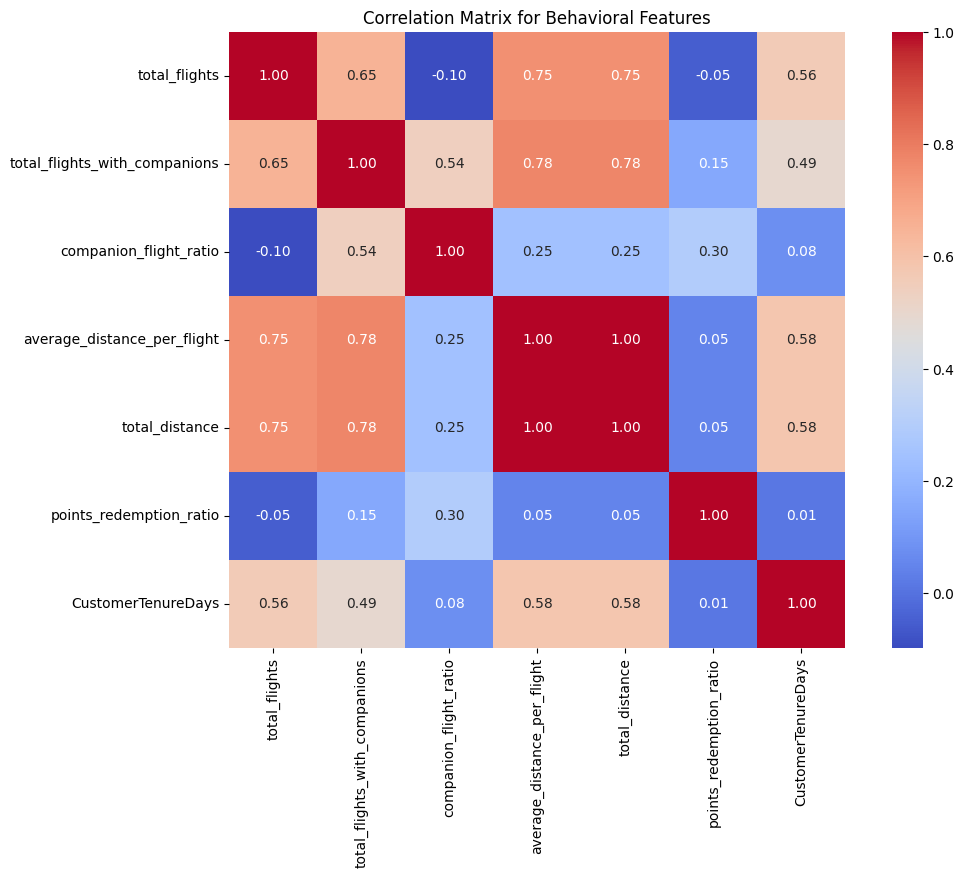

Pairs with correlation > 0.8 or < -0.8:
average_distance_per_flight  total_distance    1.0
dtype: float64


In [9]:
# Check for correlation inside the behavioral features
plt.figure(figsize=(12, 8))
correlation_matrix = df_behavioral.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix for Behavioral Features")
plt.show()

threshold = 0.8
unstacked = correlation_matrix.unstack()
high_corr = unstacked[(unstacked.abs() > threshold) & (unstacked != 1.0)].drop_duplicates()

print(f"Pairs with correlation > {threshold} or < -{threshold}:")
print(high_corr)

We can identify highly correlated features and drop the following features:

 - average_distance_per_flight

In [10]:
# Delete the feature average_distance_per_flight
df_behavioral = df_behavioral.drop(columns=['average_distance_per_flight'])
df_behavioral.head()


# Delete them from behavioral_features list
behavioral_features.remove('average_distance_per_flight')


# 3 Value Based Clustering 

Clustering Methods:

Methods to use

- KMeans++ Clustering
- Density Clustering
    - Mean Shift
    - DBSCAN
- Probability-based Models
    - Gaussian Mixture Models
- Self Organizing Maps

## 3.1 KMeans++ Clustering

First we start with KMeans++ Clustering Method and use it as our baseline to compare with other Clustering Methods.

Running K-Means optimization for K=2 to 15...

Top 3 Configurations by Silhouette:


,K,Inertia,R2_Score,Silhouette,Inertia_Pct_Change,R2_Pct_Change,Sil_Pct_Change
0,2,59733.711080,0.392023,0.416592,NaN,NaN,NaN
1,3,49778.357586,0.493350,0.398061,-16.666223,25.847125,-4.448141
3,5,38069.349563,0.612526,0.245747,-12.375970,9.811178,1.559047


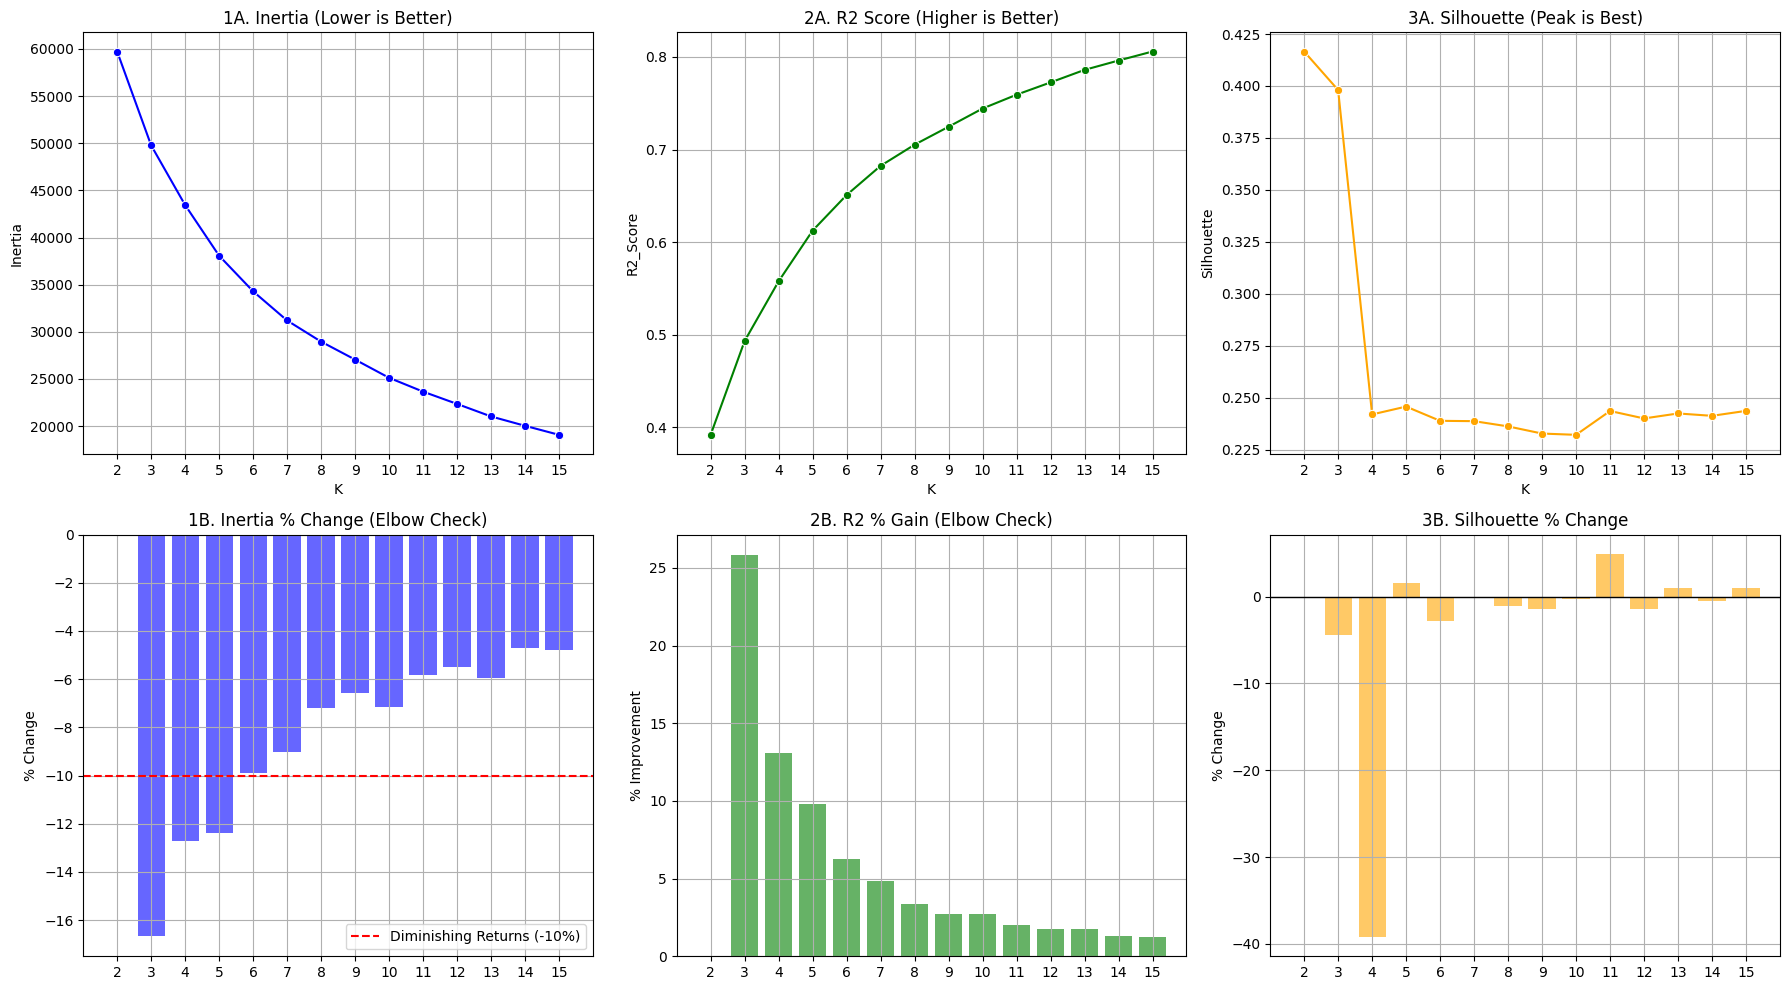

In [11]:
# --- K-Means Optimization with Gradients ---

def optimize_kmeans_gradient(data, k_range=range(2, 16)):
    """
    Runs KMeans++ and calculates Inertia, R2, and Silhouette,
    PLUS their percentage changes (gradients) to find the Elbow.
    """
    X = data.values if isinstance(data, pd.DataFrame) else data
    
    # Calculate Total Sum of Squares (SST) - Once
    centroid = X.mean(axis=0)
    sst = np.sum((X - centroid) ** 2)
    
    results_ms = []
    
    print(f"Running K-Means optimization for K={k_range.start} to {k_range.stop - 1}...")
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        kmeans.fit(X)
        
        ssw = kmeans.inertia_
        r2 = 1 - (ssw / sst)
        sil = silhouette_score(X, kmeans.labels_)
        
        results_ms.append({
            'K': k,
            'Inertia': ssw,
            'R2_Score': r2,
            'Silhouette': sil
        })
        
    df = pd.DataFrame(results_ms)
    
    # Calculate Gradients (Percentage Change)
    # Note: We multiply by 100 to get percentages
    df['Inertia_Pct_Change'] = df['Inertia'].pct_change() * 100
    df['R2_Pct_Change'] = df['R2_Score'].pct_change() * 100
    df['Sil_Pct_Change'] = df['Silhouette'].pct_change() * 100
    
    return df

# --- EXECUTION ---
results_df = optimize_kmeans_gradient(df_behavioral, k_range=range(2, 16))

# Display Top Results (Sorted by Silhouette)
print("\nTop 3 Configurations by Silhouette:")
display(results_df.sort_values('Silhouette', ascending=False).head(3))

# --- VISUALIZATION (2x3 Grid) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Define common X limits so top and bottom align perfectly
# We add -1 and +1 padding so the points aren't squished against the wall
x_min, x_max = results_df['K'].min() - 1, results_df['K'].max() + 1

# ---------------------------------------------------------
# COLUMN 1: INERTIA
# ---------------------------------------------------------
# Top: Absolute (Line)
sns.lineplot(data=results_df, x='K', y='Inertia', marker='o', ax=axes[0,0], color='blue')
axes[0,0].set_title('1A. Inertia (Lower is Better)')
axes[0,0].grid(True)
axes[0,0].set_xticks(results_df['K'])
axes[0,0].set_xlim(x_min, x_max)  # <--- Align X-Axis

# Bottom: Gradient (Bar) - USING PLT.BAR FOR ALIGNMENT
axes[1,0].bar(results_df['K'], results_df['Inertia_Pct_Change'], color='blue', alpha=0.6)
axes[1,0].set_title('1B. Inertia % Change (Elbow Check)')
axes[1,0].set_ylabel('% Change')
axes[1,0].axhline(-10, color='red', linestyle='--', label='Diminishing Returns (-10%)')
axes[1,0].grid(True)
axes[1,0].legend()
axes[1,0].set_xticks(results_df['K'])
axes[1,0].set_xlim(x_min, x_max)  # <--- Align X-Axis


# ---------------------------------------------------------
# COLUMN 2: R2 SCORE
# ---------------------------------------------------------
# Top: Absolute (Line)
sns.lineplot(data=results_df, x='K', y='R2_Score', marker='o', ax=axes[0,1], color='green')
axes[0,1].set_title('2A. R2 Score (Higher is Better)')
axes[0,1].grid(True)
axes[0,1].set_xticks(results_df['K'])
axes[0,1].set_xlim(x_min, x_max) # <--- Align X-Axis

# Bottom: Gradient (Bar) - USING PLT.BAR FOR ALIGNMENT
axes[1,1].bar(results_df['K'], results_df['R2_Pct_Change'], color='green', alpha=0.6)
axes[1,1].set_title('2B. R2 % Gain (Elbow Check)')
axes[1,1].set_ylabel('% Improvement')
axes[1,1].grid(True)
axes[1,1].set_xticks(results_df['K'])
axes[1,1].set_xlim(x_min, x_max) # <--- Align X-Axis


# ---------------------------------------------------------
# COLUMN 3: SILHOUETTE
# ---------------------------------------------------------
# Top: Absolute (Line)
sns.lineplot(data=results_df, x='K', y='Silhouette', marker='o', ax=axes[0,2], color='orange')
axes[0,2].set_title('3A. Silhouette (Peak is Best)')
axes[0,2].grid(True)
axes[0,2].set_xticks(results_df['K'])
axes[0,2].set_xlim(x_min, x_max) # <--- Align X-Axis

# Bottom: Gradient (Bar) - USING PLT.BAR FOR ALIGNMENT
axes[1,2].bar(results_df['K'], results_df['Sil_Pct_Change'], color='orange', alpha=0.6)
axes[1,2].set_title('3B. Silhouette % Change')
axes[1,2].set_ylabel('% Change')
axes[1,2].axhline(0, color='black', linewidth=1)
axes[1,2].grid(True)
axes[1,2].set_xticks(results_df['K'])
axes[1,2].set_xlim(x_min, x_max) # <--- Align X-Axis

plt.tight_layout()
plt.show()

Explanation for the chosen K

- For Inertia Change we put threshold to 10% change in inertia. 
- For R2 Gain we can see that after K=5 the R2 Gain is below 5% for the next K. 
- For Silhouette Score we can see that after K=5 the Silhouette Score is decreasing dratstically.

In [12]:
# --- Manual Selection & Saving (K-Means) ---

# 1. INPUT CHOSEN K HERE
selected_k = 7  # <--- Update this based on Elbow/Gradient plots!

print(f"Finalizing K-Means++ with K={selected_k}...")

# 2. Fit the Final Model
X_final = df_behavioral.values 

kmeans_final = KMeans(n_clusters=selected_k, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_final)

# 3. Create a Dataframe for evaluation and save it there
df_behavioral_evaluation = df_behavioral.copy()
df_behavioral_evaluation['cluster_kmeans'] = kmeans_labels

# 4. Final Confirmation & Stats
sil_score = silhouette_score(X_final, kmeans_labels)
print(f"Done. 'cluster_kmeans' column added.")
print(f"Final Inertia: {kmeans_final.inertia_:.2f}")
print(f"Final Silhouette Score: {sil_score:.4f}")

# Optional: Show distribution
print("\nCluster Distribution:")
print(df_behavioral_evaluation['cluster_kmeans'].value_counts().sort_index())

Finalizing K-Means++ with K=7...
Done. 'cluster_kmeans' column added.
Final Inertia: 31199.64
Final Silhouette Score: 0.2387

Cluster Distribution:
cluster_kmeans
0    2279
1    3801
2    1208
3    1489
4    3849
5    3733
6      16
Name: count, dtype: int64


## 3.2 Density based & Probabilistic Clustering

### 3.2.1 Mean Shift Clustering

Analyzing Mean Shift for quantiles: [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]...

Mean Shift Analysis Results with Gradients:


,Quantile,Bandwidth,n_clusters,Silhouette,Davies-Bouldin,R2 Score,Clusters_Pct_Change,Sil_Pct_Change,DB_Pct_Change,R2_Pct_Change
0,0.10,1.6410,17,0.361,0.719,0.561,0.000000,0.000000,0.000000,0.000000
1,0.15,1.8653,17,0.407,0.623,0.542,0.000000,12.742382,-13.351878,-3.386809
2,0.20,2.0584,13,0.416,0.585,0.495,-23.529412,2.211302,-6.099518,-8.671587
3,0.25,2.2315,11,0.502,0.511,0.114,-15.384615,20.673077,-12.649573,-76.969697
4,0.30,2.3959,9,0.537,0.420,0.107,-18.181818,6.972112,-17.808219,-6.140351
5,0.35,2.5430,8,0.543,0.523,0.106,-11.111111,1.117318,24.523810,-0.934579
6,0.40,2.6869,9,0.544,0.421,0.106,12.500000,0.184162,-19.502868,0.000000
7,0.45,2.8225,8,0.544,0.522,0.106,-11.111111,0.000000,23.990499,0.000000
8,0.50,2.9566,8,0.689,0.411,0.084,0.000000,26.654412,-21.264368,-20.754717


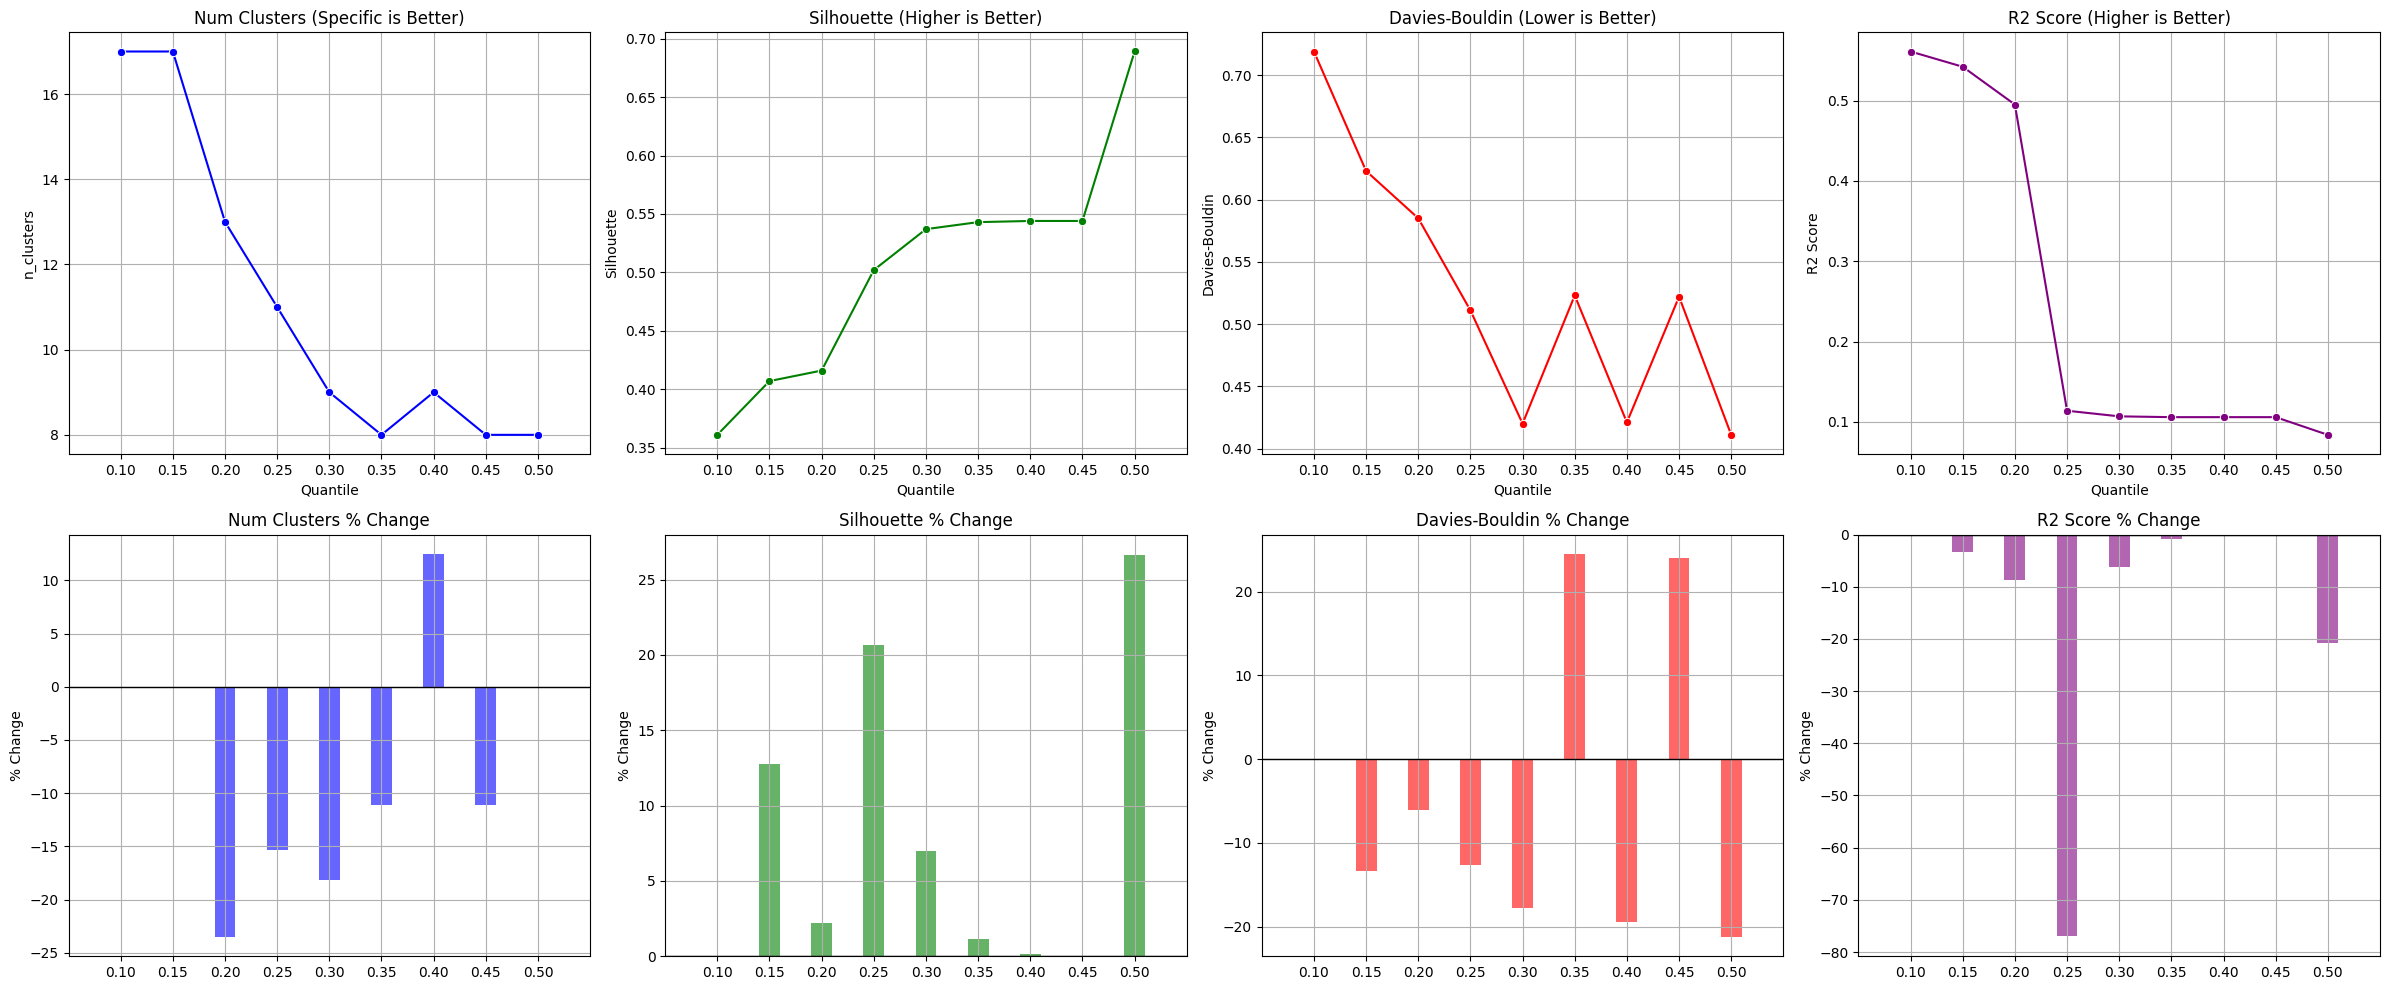

In [13]:
# --- Optimization & Visualization ---

def analyze_meanshift_quantiles(data, quantile_range=[0.1, 0.15, 0.2, 0.25, 0.3]):
    """
    Test different quantiles for Mean Shift and plot the trade-offs.
    Does NOT save to the dataframe yet.
    """
    X = data.values if isinstance(data, pd.DataFrame) else data
    
    # Calculate Global Centroid for R2
    centroid_global = X.mean(axis=0)
    sst = np.sum((X - centroid_global) ** 2)
    
    results = []
    
    print(f"Analyzing Mean Shift for quantiles: {quantile_range}...")
    
    for q in quantile_range:
        try:
            # 1. Estimate Bandwidth
            bandwidth = estimate_bandwidth(X, quantile=q, n_samples=min(500, len(X)))
            
            if bandwidth <= 0:
                continue
            
            # 2. Run Mean Shift
            ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
            ms.fit(X)
            
            labels = ms.labels_
            n_clusters = len(np.unique(labels))
            
            # 3. Calculate Metrics
            if 1 < n_clusters < len(X):
                sil = silhouette_score(X, labels)
                db_score = davies_bouldin_score(X, labels)
                
                # R2 Score Calculation
                ssw = 0
                for k in np.unique(labels):
                    cluster_data = X[labels == k]
                    ssw += np.sum((cluster_data - cluster_data.mean(axis=0)) ** 2)
                r2 = 1 - (ssw / sst)
            else:
                sil, db_score, r2 = -1, 999, 0
            
            results.append({
                'Quantile': q,
                'Bandwidth': round(bandwidth, 4),
                'n_clusters': n_clusters,
                'Silhouette': round(sil, 3),
                'Davies-Bouldin': round(db_score, 3),
                'R2 Score': round(r2, 3)
            })
            
        except Exception as e:
            print(f"Skipping quantile {q}: {e}")

    return pd.DataFrame(results)

# --- EXECUTE ANALYSIS ---
# Use your scaled dataframe here
ms_metrics_df = analyze_meanshift_quantiles(df_behavioral, quantile_range=[0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5])

# --- CALCULATE GRADIENTS (Derivatives) ---
ms_metrics_df['Clusters_Pct_Change'] = ms_metrics_df['n_clusters'].pct_change().fillna(0) * 100
ms_metrics_df['Sil_Pct_Change'] = ms_metrics_df['Silhouette'].pct_change().fillna(0) * 100
ms_metrics_df['DB_Pct_Change'] = ms_metrics_df['Davies-Bouldin'].pct_change().fillna(0) * 100
ms_metrics_df['R2_Pct_Change'] = ms_metrics_df['R2 Score'].pct_change().fillna(0) * 100

# Display Table
print("\nMean Shift Analysis Results with Gradients:")
display(ms_metrics_df)

# --- VISUALIZATION (2x4 Grid) ---
if not ms_metrics_df.empty:
    fig, axes = plt.subplots(2, 4, figsize=(24, 10))

    # Determine Bar Width dynamically (approx 40% of the step size to look good)
    # E.g., if step is 0.05, width will be 0.02
    if len(ms_metrics_df) > 1:
        step_size = ms_metrics_df['Quantile'].diff().mean()
        bar_width = step_size * 0.4
    else:
        step_size = 0.05
        bar_width = 0.02

    # Define common X limits so top and bottom align perfectly
    x_min = ms_metrics_df['Quantile'].min() - step_size
    x_max = ms_metrics_df['Quantile'].max() + step_size

    # --- HELPER PLOTTING FUNCTION ---
    def plot_ms_pair(col_idx, metric_col, change_col, title_base, color, better='Higher'):
        # Top: Absolute (Line)
        sns.lineplot(data=ms_metrics_df, x='Quantile', y=metric_col, marker='o', ax=axes[0, col_idx], color=color)
        axes[0, col_idx].set_title(f'{title_base} ({better} is Better)')
        axes[0, col_idx].grid(True)
        axes[0, col_idx].set_xticks(ms_metrics_df['Quantile'])
        axes[0, col_idx].set_xlim(x_min, x_max)

        # Bottom: Gradient (Bar) - Using plt.bar for numeric alignment
        axes[1, col_idx].bar(ms_metrics_df['Quantile'], ms_metrics_df[change_col], color=color, alpha=0.6, width=bar_width)
        axes[1, col_idx].set_title(f'{title_base} % Change')
        axes[1, col_idx].set_ylabel('% Change')
        axes[1, col_idx].axhline(0, color='black', linewidth=1)
        axes[1, col_idx].grid(True)
        axes[1, col_idx].set_xticks(ms_metrics_df['Quantile'])
        axes[1, col_idx].set_xlim(x_min, x_max)

    # 1. Clusters (Blue)
    plot_ms_pair(0, 'n_clusters', 'Clusters_Pct_Change', 'Num Clusters', 'blue', better='Specific')

    # 2. Silhouette (Green)
    plot_ms_pair(1, 'Silhouette', 'Sil_Pct_Change', 'Silhouette', 'green', better='Higher')

    # 3. Davies-Bouldin (Red)
    plot_ms_pair(2, 'Davies-Bouldin', 'DB_Pct_Change', 'Davies-Bouldin', 'red', better='Lower')

    # 4. R2 Score (Purple)
    plot_ms_pair(3, 'R2 Score', 'R2_Pct_Change', 'R2 Score', 'purple', better='Higher')

    plt.tight_layout()
    plt.show()

- Write Here the explanation for the number of quantile used to determine as best bandwidth for Mean Shift Clustering.


- Number of Clusters: We are looking for a number below 20 for better interpretability and actionability of the clusters.
- Silhoutte Score: Should be high
- Davies Bouldin Score: Should be low
- R2 Score: Should be high

In [14]:
# --- Manual Selection & Saving ---

# 1. INPUT YOUR CHOSEN QUANTILE HERE
selected_quantile = 0.2  # <--- Update this based on the plots above!

print(f"Finalizing Mean Shift with Quantile: {selected_quantile}...")

# 2. Re-fit the specific model
X_final = df_behavioral.values
final_bandwidth = estimate_bandwidth(X_final, quantile=selected_quantile, n_samples=min(500, len(X_final)))

ms_final = MeanShift(bandwidth=final_bandwidth, bin_seeding=True)
ms_labels = ms_final.fit_predict(X_final)

# 3. Save to DataFrame
df_behavioral_evaluation['cluster_meanshift'] = ms_labels

# 4. Final Confirmation
n_clusters_final = len(np.unique(ms_labels))
print(f"Done. 'cluster_meanshift' column added with {n_clusters_final} clusters.")
print(f"Bandwidth used: {final_bandwidth:.4f}")

Finalizing Mean Shift with Quantile: 0.2...
Done. 'cluster_meanshift' column added with 13 clusters.
Bandwidth used: 2.0584


In [15]:
# Print the columns of df_behavioral_evaluation
print(df_behavioral_evaluation.columns)

Index(['total_flights', 'total_flights_with_companions',
       'companion_flight_ratio', 'total_distance', 'points_redemption_ratio',
       'CustomerTenureDays', 'cluster_kmeans', 'cluster_meanshift'],
      dtype='object')


### 3.2.2 DBSCAN Clustering

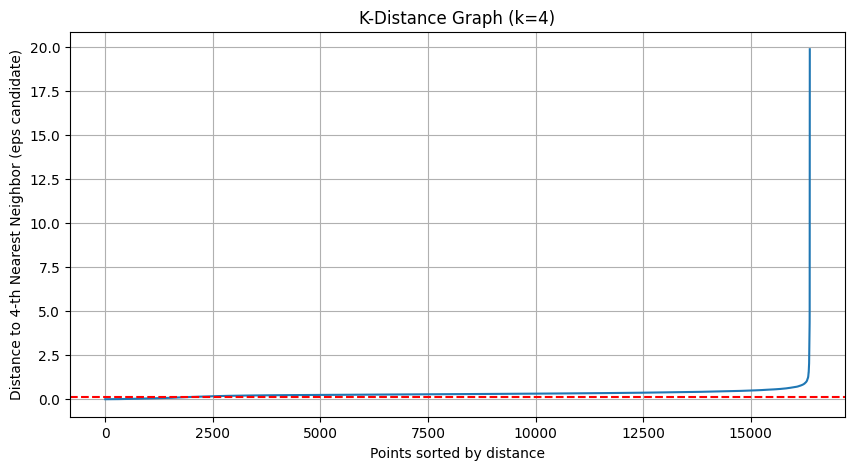

In [ ]:
# --- DBSCAN Analysis (K-Distance Graph) ---

def plot_k_distance(data, k=4):
    """
    Plots the k-distance graph to help find the optimal 'eps' for DBSCAN.
    The 'knee' of the curve suggests the optimal eps value.
    """
    X = data.values if hasattr(data, 'values') else data
    
    # Calculate nearest neighbors
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(X)
    distances, indices = neighbors_fit.kneighbors(X)
    
    # Sort distance values by the k-th neighbor (column index k-1)
    distances = np.sort(distances[:, k-1], axis=0)
    
    plt.figure(figsize=(10, 5))
    plt.plot(distances)
    plt.title(f"K-Distance Graph (k={k})")
    plt.ylabel(f"Distance to {k}-th Nearest Neighbor (eps candidate)")
    plt.xlabel("Points sorted by distance")

    # Plot knee point (optional) 
    plt.axhline(y=1, color='r', linestyle='--', label='Potential eps (elbow)')


    plt.grid(True)
    plt.show()

# --- EXECUTION ---
# Look for the point of maximum curvature (the "knee")
plot_k_distance(df_behavioral, k=4)

Analyzing DBSCAN with fixed eps=0.1 for min_samples: [10, 15, 20, 25, 30, 40, 50, 60, 70, 80]...

DBSCAN Analysis Results with Gradients :


,Min_Samples,Clusters,Noise_Pct,Silhouette,Davies-Bouldin,Noise_Pct_Change,Clusters_Pct_Change,Sil_Pct_Change
0,10,6,91.2,0.280,0.465,0.000000,0.000000,0.000000
1,15,6,92.3,0.749,0.475,1.206140,0.000000,167.500000
2,20,4,93.1,0.341,1.197,0.866739,-33.333333,-54.472630
3,25,3,93.6,0.323,1.470,0.537057,-25.000000,-5.278592
4,30,3,93.8,0.328,1.417,0.213675,0.000000,1.547988
5,40,4,94.3,0.257,0.984,0.533049,33.333333,-21.646341
6,50,4,95.1,0.272,0.838,0.848356,0.000000,5.836576
7,60,2,96.2,0.869,0.150,1.156677,-50.000000,219.485294
8,70,3,96.4,0.560,0.367,0.207900,50.000000,-35.558113
9,80,2,97.2,0.916,0.106,0.829876,-33.333333,63.571429


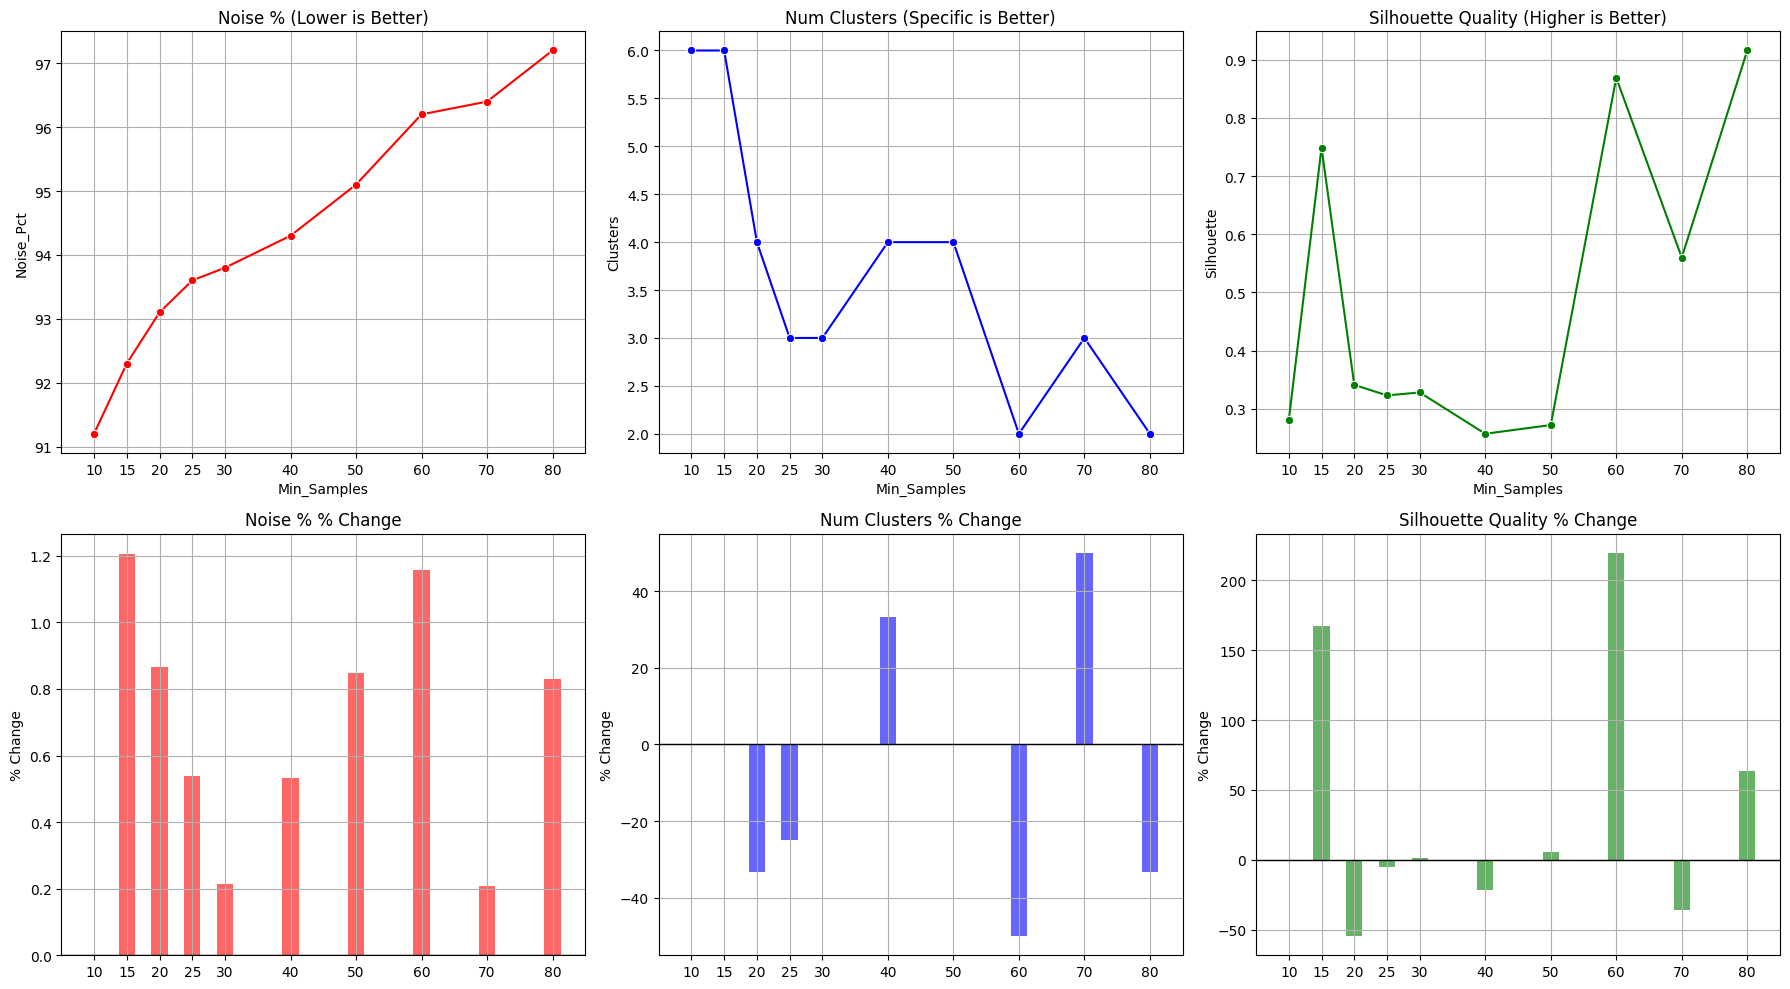

In [17]:
# --- DBSCAN Analysis (Fixed Eps, Variable Min_Samples) ---

def analyze_dbscan_min_samples(data, fixed_eps, ms_range=[5, 10, 15, 20, 25, 30, 35, 40]):
    """
    Tests different min_samples values for a fixed eps and reports metrics.
    """
    X = data.values if isinstance(data, pd.DataFrame) else data
    results = []
    
    print(f"Analyzing DBSCAN with fixed eps={fixed_eps} for min_samples: {ms_range}...")
    
    for ms in ms_range:
        # Run DBSCAN
        db = DBSCAN(eps=fixed_eps, min_samples=ms, n_jobs=-1)
        labels = db.fit_predict(X)
        
        # Basic Stats
        # Count clusters (excluding noise -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        # Calculate Noise Percentage
        n_noise = list(labels).count(-1)
        noise_pct = n_noise / len(labels)
        
        # Evaluation (Only if we have valid clusters)
        if n_clusters > 1:
            # Filter noise for metrics
            mask = labels != -1
            if sum(mask) > 2:
                sil = silhouette_score(X[mask], labels[mask])
                db_score = davies_bouldin_score(X[mask], labels[mask])
            else:
                sil, db_score = -1, 999
        else:
            sil, db_score = -1, 999
        
        results.append({
            'Min_Samples': ms,
            'Clusters': n_clusters,
            'Noise_Pct': round(noise_pct * 100, 1), # Converted to %
            'Silhouette': round(sil, 3),
            'Davies-Bouldin': round(db_score, 3)
        })
            
    return pd.DataFrame(results)

# --- EXECUTE ANALYSIS ---
db_metrics_df = analyze_dbscan_min_samples(df_behavioral, fixed_eps=0.1, ms_range=[10, 15, 20, 25, 30, 40, 50, 60, 70, 80])

# --- CALCULATE GRADIENTS (Derivatives) ---
# We use fillna(0) to handle the first row having no previous value
db_metrics_df['Noise_Pct_Change'] = db_metrics_df['Noise_Pct'].pct_change().fillna(0) * 100
db_metrics_df['Clusters_Pct_Change'] = db_metrics_df['Clusters'].pct_change().fillna(0) * 100
db_metrics_df['Sil_Pct_Change'] = db_metrics_df['Silhouette'].pct_change().fillna(0) * 100

# Display Table
print("\nDBSCAN Analysis Results with Gradients :")
display(db_metrics_df)

# --- VISUALIZATION (2x3 Grid) ---
if not db_metrics_df.empty:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Determine Bar Width dynamically (approx 50% of the minimum step size)
    # This handles cases where your range steps change (e.g. 5, 5, then 10)
    if len(db_metrics_df) > 1:
        min_step = db_metrics_df['Min_Samples'].diff().min()
        bar_width = min_step * 0.5 if min_step > 0 else 1
    else:
        bar_width = 1

    # Define common X limits so top and bottom align perfectly
    x_min = db_metrics_df['Min_Samples'].min() - (bar_width * 2)
    x_max = db_metrics_df['Min_Samples'].max() + (bar_width * 2)

    # --- HELPER FUNCTION FOR CONSISTENCY ---
    def plot_dbscan_pair(col_idx, metric_col, change_col, title_base, color, better='Lower'):
        # Top: Absolute (Line)
        sns.lineplot(data=db_metrics_df, x='Min_Samples', y=metric_col, marker='o', ax=axes[0, col_idx], color=color)
        axes[0, col_idx].set_title(f'{title_base} ({better} is Better)')
        axes[0, col_idx].grid(True)
        axes[0, col_idx].set_xticks(db_metrics_df['Min_Samples'])
        axes[0, col_idx].set_xlim(x_min, x_max)

        # Bottom: Gradient (Bar) - Using plt.bar for numeric alignment
        axes[1, col_idx].bar(db_metrics_df['Min_Samples'], db_metrics_df[change_col], color=color, alpha=0.6, width=bar_width)
        axes[1, col_idx].set_title(f'{title_base} % Change')
        axes[1, col_idx].set_ylabel('% Change')
        axes[1, col_idx].axhline(0, color='black', linewidth=1)
        axes[1, col_idx].grid(True)
        axes[1, col_idx].set_xticks(db_metrics_df['Min_Samples'])
        axes[1, col_idx].set_xlim(x_min, x_max)

    # 1. Noise Percentage (Red - Critical for DBSCAN)
    plot_dbscan_pair(0, 'Noise_Pct', 'Noise_Pct_Change', 'Noise %', 'red', better='Lower')

    # 2. Number of Clusters (Blue)
    plot_dbscan_pair(1, 'Clusters', 'Clusters_Pct_Change', 'Num Clusters', 'blue', better='Specific')

    # 3. Silhouette (Green)
    plot_dbscan_pair(2, 'Silhouette', 'Sil_Pct_Change', 'Silhouette Quality', 'green', better='Higher')

    plt.tight_layout()
    plt.show()

Explanation for selected_min_samples

- Low Noise
- And High Silhoute Score

In [18]:
# --- Manual Selection & Saving ---

# 1. Input eps and min_samples
selected_eps = 0.1          # Kept fixed
selected_min_samples = 15    # <--- Based on the table above!

print(f"Finalizing DBSCAN with eps={selected_eps}, min_samples={selected_min_samples}...")

# 2. Re-fit the specific model
db_final = DBSCAN(eps=selected_eps, min_samples=selected_min_samples, n_jobs=-1)
db_labels = db_final.fit_predict(df_behavioral)

# 3. Save to DataFrame
df_behavioral_evaluation['cluster_dbscan'] = db_labels

# 4. Final Confirmation
n_clusters_final = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_pct_final = list(db_labels).count(-1) / len(db_labels)

print(f"Done. 'cluster_dbscan' column added.")
print(f"Stats: {n_clusters_final} Clusters found.")
print(f"Noise Level: {noise_pct_final:.1%} (Total {list(db_labels).count(-1)} noise points)")

Finalizing DBSCAN with eps=0.1, min_samples=15...
Done. 'cluster_dbscan' column added.
Stats: 6 Clusters found.
Noise Level: 92.3% (Total 15111 noise points)


### 3.2.3 Gaussian Mixture Models

Analyzing GMM for components: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]...


/var/folders/91/np610d0s2kq3t3kpltqrl7b40000gn/T/ipykernel_20251/3016146181.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


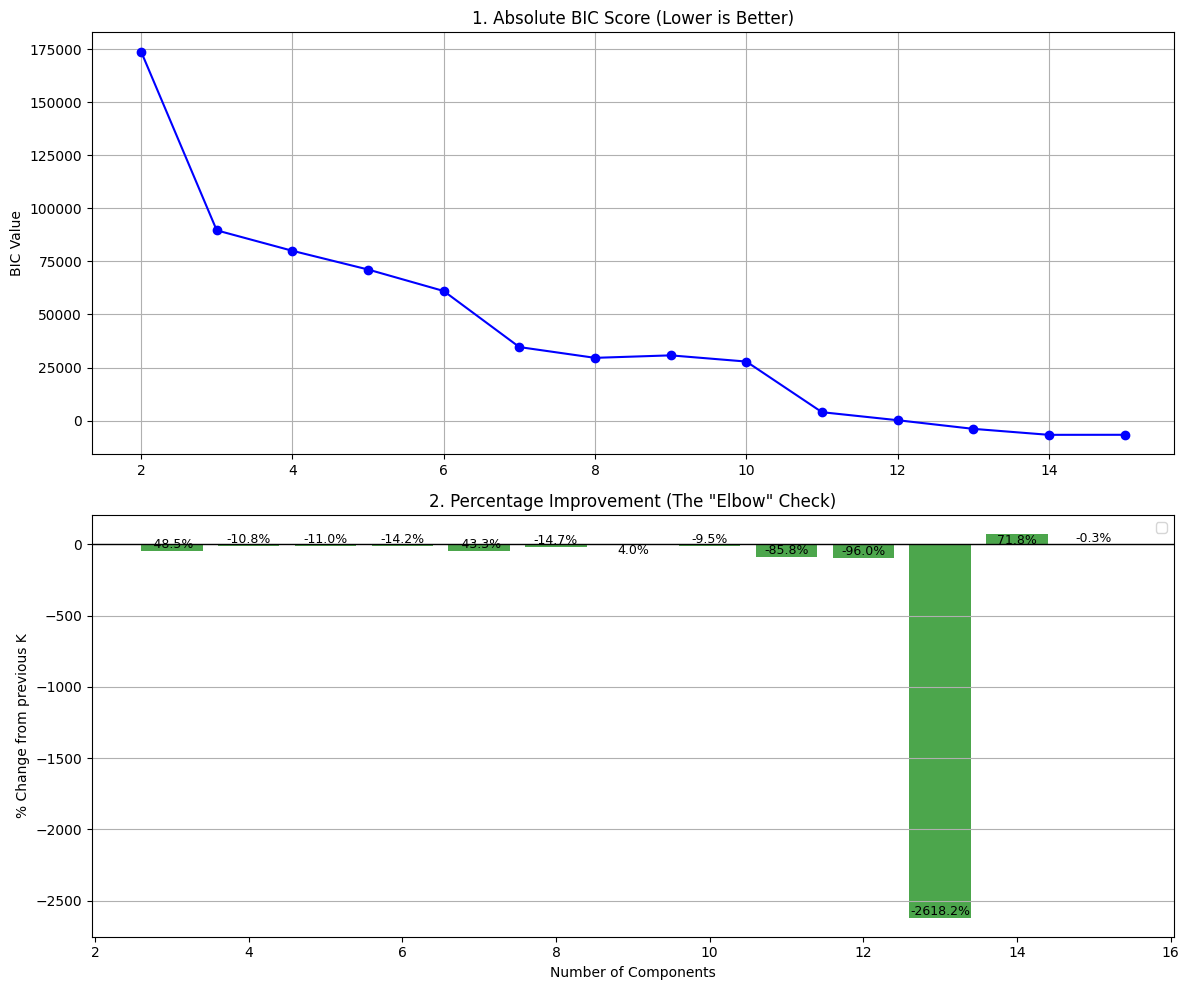

In [19]:
# --- GMM Analysis with Percentage Decrease ---


def analyze_gmm_gradient(data, n_range=range(2, 16)):
    """
    Calculates AIC/BIC and their percentage decrease (gradient) 
    to help find the 'Elbow' point.
    """
    X = data.values if isinstance(data, pd.DataFrame) else data
    results = []
    
    print(f"Analyzing GMM for components: {list(n_range)}...")
    
    for n in n_range:
        gmm = GaussianMixture(n_components=n, n_init=10, random_state=42)
        gmm.fit(X)
        
        results.append({
            'n_components': n,
            'AIC': gmm.aic(X),
            'BIC': gmm.bic(X)
        })
        
    df = pd.DataFrame(results)
    
    # Calculate Percentage Change (The "Elbow" Logic)
    # Formula: (Current - Previous) / Previous * 100
    df['BIC_Pct_Change'] = df['BIC'].pct_change() * 100
    df['AIC_Pct_Change'] = df['AIC'].pct_change() * 100
    
    return df

# --- EXECUTE ANALYSIS ---
gmm_results = analyze_gmm_gradient(df_behavioral, n_range=range(2, 16))


# --- VISUALIZATION ---
if not gmm_results.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: Raw BIC Scores (The Curve)
    ax1.plot(gmm_results['n_components'], gmm_results['BIC'], marker='o', color='blue', label='BIC Score')
    ax1.set_title('1. Absolute BIC Score (Lower is Better)')
    ax1.set_ylabel('BIC Value')
    ax1.grid(True)
    
    # Plot 2: Percentage Change (The Elbow)
    # We drop the first NaN value for plotting
    plot_data = gmm_results.dropna()
    bars = ax2.bar(plot_data['n_components'], plot_data['BIC_Pct_Change'], color='green', alpha=0.7)
    
    # Add labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom' if height < 0 else 'top', fontsize=9)

    ax2.set_title('2. Percentage Improvement (The "Elbow" Check)')
    ax2.set_ylabel('% Change from previous K')
    ax2.set_xlabel('Number of Components')
    ax2.axhline(0, color='black', linewidth=1)
    ax2.legend()
    ax2.grid(True, axis='y')
    
    plt.tight_layout()
    plt.show()

Explantation for the number of components used in GMM

In [20]:
# --- Manual Selection & Saving ---

# 1. INPUT CHOSEN COMPONENTS HERE
selected_n_components = 6  # <--- Update based on the Bar Chart!

print(f"Finalizing GMM with {selected_n_components} components...")

# 2. Fit Final Model
X_final = df_behavioral.values 
gmm_final = GaussianMixture(n_components=selected_n_components, n_init=10, random_state=42)
gmm_labels = gmm_final.fit_predict(X_final)

# 3. Probability & Uncertainty
probs = gmm_final.predict_proba(X_final)
uncertainty = 1 - probs.max(axis=1)
print(f"Average Uncertainty: {uncertainty.mean():.4f}")

# Calculate R2 Score for GMM
centroid_global = X_final.mean(axis=0)
sst = np.sum((X_final - centroid_global) ** 2)
ssw = 0
for k in np.unique(gmm_labels):
    cluster_data = X_final[gmm_labels == k]
    ssw += np.sum((cluster_data - cluster_data.mean(axis=0)) ** 2)
r2_gmm = 1 - (ssw / sst)
print(f"GMM R2 Score: {r2_gmm:.4f}")

# 4. Save
df_behavioral_evaluation['cluster_gmm'] = gmm_labels
df_behavioral_evaluation['gmm_uncertainty'] = uncertainty

print("Done. Saved 'cluster_gmm' and 'gmm_uncertainty'.")

Finalizing GMM with 6 components...
Average Uncertainty: 0.0580
GMM R2 Score: 0.5612
Done. Saved 'cluster_gmm' and 'gmm_uncertainty'.


## 3.3 Neural Network Based Clustering

### 3.3.1 Self Organizing Maps

In [21]:
# --- SOM Training with QE/TE Metrics ---

# Suppress numerical warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

def train_som_fast_with_metrics(data, n_iter, grid_size):
    """
    Trains a SOM using Batch Training and calculates 
    Quantization and Topographic error improvement.
    """
    # 1. Convert to numpy if needed
    X = data.values if isinstance(data, pd.DataFrame) else data
    N = X.shape[0]
    
    print(f"Initializing SOM ({grid_size}x{grid_size}) for {N} samples...")
    
    # 2. Initialize SOM
    som = MiniSom(x=grid_size, 
                  y=grid_size, 
                  input_len=X.shape[1],
                  sigma=2.0,
                  learning_rate=0.5,
                  neighborhood_function='gaussian',
                  topology='hexagonal',
                  random_seed=42
                  )
    
    # Initialize random weights
    som.random_weights_init(X)
    
    # --- METRICS BEFORE TRAINING ---
    print("Calculating baseline metrics (Before Training)...")
    qe_before = som.quantization_error(X)
    te_before = som.topographic_error(X)
    print(f"  > Baseline QE: {qe_before:.4f}")
    print(f"  > Baseline TE: {te_before:.4f}")
    
    # 3. Train (Batch Mode)
    print(f"\nTraining for {n_iter} iterations (Batch Mode)...")
    start_time = time.time()
    
    som.train_batch(X, num_iteration=n_iter, verbose=True)
    
    elapsed = time.time() - start_time
    print(f"Training Complete in {elapsed:.2f} seconds.")
    
    # --- METRICS AFTER TRAINING ---
    print("\nCalculating final metrics (After Training)...")
    qe_after = som.quantization_error(X)
    te_after = som.topographic_error(X)
    
    # --- COMPARISON OUTPUT ---
    print("-" * 60)
    print("SOM Performance Improvement:")
    print("-" * 60)
    
    # Calculate % improvement (Handle division by zero safety)
    qe_improv = (1 - qe_after/qe_before)*100 if qe_before > 0 else 0
    te_improv = (1 - te_after/te_before)*100 if te_before > 0 else 0
    
    print(f"Quantization Error (QE): {qe_before:.4f} → {qe_after:.4f} ({qe_improv:.1f}% improvement)")
    print(f"Topographic Error (TE):  {te_before:.4f} → {te_after:.4f} ({te_improv:.1f}% improvement)")
    print("-" * 60)
    
    return som, (grid_size, grid_size)

# --- EXECUTION ---
# Make sure 'df_behavioral' contains ONLY the columns you want the SOM to learn from.
som_model, som_grid = train_som_fast_with_metrics(df_behavioral, grid_size=25, n_iter=10000)

Initializing SOM (25x25) for 16375 samples...
Calculating baseline metrics (Before Training)...
  > Baseline QE: 0.4506
  > Baseline TE: 0.9917

Training for 10000 iterations (Batch Mode)...
 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.4735165094824079
Training Complete in 0.35 seconds.

Calculating final metrics (After Training)...
------------------------------------------------------------
SOM Performance Improvement:
------------------------------------------------------------
Quantization Error (QE): 0.4506 → 0.4735 (-5.1% improvement)
Topographic Error (TE):  0.9917 → 0.1443 (85.4% improvement)
------------------------------------------------------------


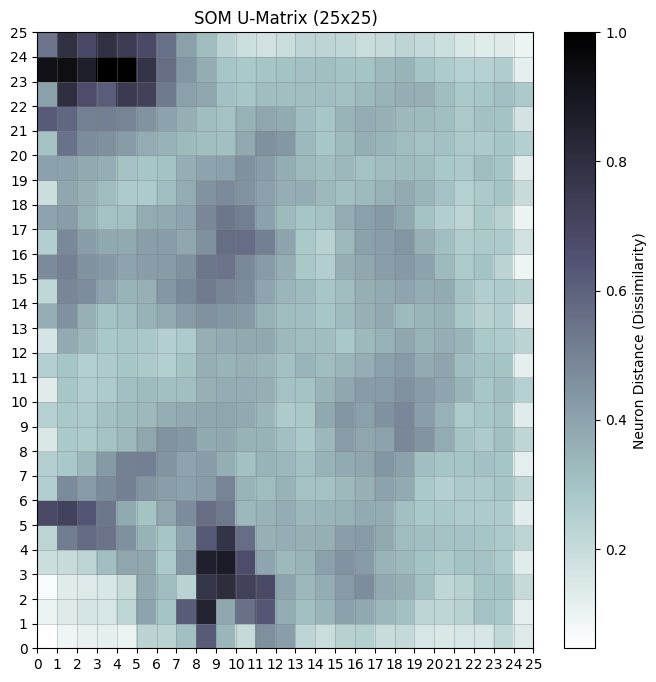

In [22]:
# --- U-Matrix Visualization ---

def plot_som_topology(som, grid_size):
    """
    Plots the Unified Distance Matrix (U-Matrix).
    Darker colors = Clusters (valleys).
    Lighter colors = Boundaries (ridges).
    """
    plt.figure(figsize=(8, 8))
    
    # 1. Get the U-Matrix (distance to neighbors)
    u_matrix = som.distance_map().T
    
    # 2. Plot heatmap
    plt.pcolor(u_matrix, cmap='bone_r') 
    plt.colorbar(label='Neuron Distance (Dissimilarity)')
    
    # Add grid lines
    plt.xticks(np.arange(grid_size[0] + 1))
    plt.yticks(np.arange(grid_size[1] + 1))
    plt.grid(color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    
    plt.title(f'SOM U-Matrix ({grid_size[0]}x{grid_size[1]})')
    plt.show()

# --- EXECUTION ---
plot_som_topology(som_model, som_grid)

In [23]:
# --- Two-Stage Clustering (SOM + K-Means) ---

# 1. Extract Weights (The "Prototypes")
# Reshape to (Num_Neurons, Num_Features)
weights = som_model.get_weights().reshape(-1, df_behavioral.shape[1])

# 2. Find Best K for the Weights (Mini-Optimization)
print("Optimizing K-Means for SOM weights...")
best_k = 0
best_sil = -1
for k in range(3, 21): # Test small range suitable for map size
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(weights)
    sil = silhouette_score(weights, labels)
    print(f"K={k} -> Silhouette: {sil:.3f}")
    if sil > best_sil:
        best_sil = sil
        best_k = k

print(f"\nSelected K={best_k} for SOM Two-Stage Clustering.")

# 3. Final Clustering on Weights
km_som = KMeans(n_clusters=best_k, n_init=10, random_state=42)
neuron_clusters = km_som.fit_predict(weights)

# 4. Map Clusters back to Original Customers
# Strategy: Customer -> Best Matching Unit (Neuron) -> Neuron's Cluster
print("Mapping clusters back to customers...")
som_labels = []
X_data = df_behavioral.values

for x in X_data:
    w = som_model.winner(x)
    # Flatten 2D coordinate (x,y) to 1D index
    idx = w[0] * som_grid[1] + w[1]
    som_labels.append(neuron_clusters[idx])

# 5. Save to DataFrame
df_behavioral_evaluation['cluster_som'] = som_labels
print(f"Done. 'cluster_som' added with {best_k} clusters.")

Optimizing K-Means for SOM weights...
K=3 -> Silhouette: 0.383
K=4 -> Silhouette: 0.258
K=5 -> Silhouette: 0.263
K=6 -> Silhouette: 0.258
K=7 -> Silhouette: 0.253
K=8 -> Silhouette: 0.248
K=9 -> Silhouette: 0.238
K=10 -> Silhouette: 0.259
K=11 -> Silhouette: 0.239
K=12 -> Silhouette: 0.249
K=13 -> Silhouette: 0.256
K=14 -> Silhouette: 0.261
K=15 -> Silhouette: 0.253
K=16 -> Silhouette: 0.259
K=17 -> Silhouette: 0.258
K=18 -> Silhouette: 0.263
K=19 -> Silhouette: 0.257
K=20 -> Silhouette: 0.257

Selected K=3 for SOM Two-Stage Clustering.
Mapping clusters back to customers...
Done. 'cluster_som' added with 3 clusters.


In [24]:
# --- SOM R² Evaluation (Efficient) ---

# Prepare Data
X = df_behavioral.values
sst = np.sum((X - X.mean(axis=0)) ** 2)  # Total Variance (Calc once)

# -------------------------------------------------------
# 1. Calculate Grid R² (Stage 1: How well the Map fits)
# -------------------------------------------------------
# Get all Best Matching Units (BMUs)
# We use list comprehension as it's faster than a pandas apply loop here
winners = np.array([som_model.winner(x) for x in X])

# Retrieve the specific weight vector for each customer's BMU
# Advanced Indexing: weights[row_indices, col_indices]
weights = som_model.get_weights()
bmu_weights = weights[winners[:, 0], winners[:, 1]]

# SSW for Grid: Sum of squared distance between Customer and BMU
ssw_grid = np.sum((X - bmu_weights) ** 2)
r2_grid = 1 - (ssw_grid / sst)

# -------------------------------------------------------
# 2. Calculate Cluster R² (Stage 2: How well the Segments fit)
# -------------------------------------------------------
# This is what you compare with K-Means!
# We use the 'cluster_som' column we created in Section 5.3
labels = df_behavioral_evaluation['cluster_som'].values
unique_labels = np.unique(labels)

ssw_cluster = 0
for k in unique_labels:
    # Get data for this cluster
    cluster_data = X[labels == k]
    # Calculate Centroid (Mean of the cluster)
    centroid = cluster_data.mean(axis=0)
    # Add variance
    ssw_cluster += np.sum((cluster_data - centroid) ** 2)

r2_cluster = 1 - (ssw_cluster / sst)

# -------------------------------------------------------
# OUTPUT
# -------------------------------------------------------
print(f"SOM Grid R² (Model Fit):      {r2_grid:.4f}  (High is expected, e.g., >0.90)")
print(f"SOM Cluster R² (Segmentation): {r2_cluster:.4f}  (Used to compare with K-Means!)")

SOM Grid R² (Model Fit):      0.9216  (High is expected, e.g., >0.90)
SOM Cluster R² (Segmentation): 0.4847  (Used to compare with K-Means!)


## 3.4 Clustering Evaluation and Comparison

In [25]:
# ...existing code...
print("\nFinal Clustering Evaluation Summary:")

# 1. Prepare Data for Calculation
X = df_behavioral.values
sst = np.sum((X - X.mean(axis=0)) ** 2)  # Total Sum of Squares

# 2. Define Methods and their Column Names
clustering_methods = {
    'K-Means++': 'cluster_kmeans',
    'Mean Shift': 'cluster_meanshift',
    'DBSCAN': 'cluster_dbscan',
    'GMM': 'cluster_gmm',
    'SOM (Two-Stage)': 'cluster_som'
}

results_list = []

# 3. Loop through each method and calculate metrics
for method_name, col_name in clustering_methods.items():
    if col_name in df_behavioral_evaluation.columns:
        labels = df_behavioral_evaluation[col_name].values
        unique_labels = np.unique(labels)
        
        # --- A. Basic Counts ---
        has_noise = -1 in labels
        n_clusters = len(unique_labels) - (1 if has_noise else 0)
        noise_pct = (np.sum(labels == -1) / len(labels)) * 100 if has_noise else 0.0
        
        # --- B. Silhouette & Davies-Bouldin ---
        if n_clusters > 1:
            if has_noise:
                mask = labels != -1
                if np.sum(mask) > 1 and len(np.unique(labels[mask])) > 1:
                    sil = silhouette_score(X[mask], labels[mask])
                    db = davies_bouldin_score(X[mask], labels[mask])
                else:
                    sil, db = np.nan, np.nan
            else:
                sil = silhouette_score(X, labels)
                db = davies_bouldin_score(X, labels)
        else:
            sil, db = np.nan, np.nan
            
        # --- C. R2 Score ---
        ssw = 0
        for k in unique_labels:
            cluster_data = X[labels == k]
            ssw += np.sum((cluster_data - cluster_data.mean(axis=0)) ** 2)
        r2 = 1 - (ssw / sst)

        # --- D. Specific Metrics (New Section) ---
        specific_metric = "-"
        try:
            if method_name == 'K-Means++':
                specific_metric = f"Inertia: {kmeans_final.inertia_:.0f}"
            elif method_name == 'Mean Shift':
                specific_metric = f"Bandwidth: {final_bandwidth:.3f}"
            elif method_name == 'DBSCAN':
                specific_metric = f"Eps: {selected_eps}, MinPts: {selected_min_samples}"
            elif method_name == 'GMM':
                bic = gmm_final.bic(X)
                avg_unc = df_behavioral_evaluation['gmm_uncertainty'].mean()
                specific_metric = f"BIC: {bic:.0f} | Avg Unc: {avg_unc:.3f}"
            elif method_name == 'SOM (Two-Stage)':
                qe = som_model.quantization_error(X)
                te = som_model.topographic_error(X)
                specific_metric = f"QE: {qe:.3f} | TE: {te:.3f}"
        except NameError:
            specific_metric = "Model not in memory"

        # Append results
        results_list.append({
            'Method': method_name,
            'Clusters': n_clusters,
            'Silhouette': round(sil, 4),
            'Davies-Bouldin': round(db, 4),
            'R2 Score': round(r2, 4),
            'Noise (%)': round(noise_pct, 2),
            'Specific Metric': specific_metric
        })

# 4. Create and Display DataFrame
df_eval_summary = pd.DataFrame(results_list).set_index('Method')

# Sort by Silhouette Score for better comparison
df_eval_summary = df_eval_summary.sort_values('Silhouette', ascending=False)

print("Comparison of all Clustering Methods:")
display(df_eval_summary.style.background_gradient(cmap='YlGn', subset=['Silhouette']).background_gradient(cmap='RdYlGn_r', subset=['Davies-Bouldin']).background_gradient(cmap='YlGn', subset=['R2 Score']))


Final Clustering Evaluation Summary:
Comparison of all Clustering Methods:


,Clusters,Silhouette,Davies-Bouldin,R2 Score,Noise (%),Specific Metric
Method,,,,,,
DBSCAN,6,0.748800,0.475000,0.163300,92.280000,"Eps: 0.1, MinPts: 15"
Mean Shift,13,0.416100,0.585400,0.494700,0.000000,Bandwidth: 2.058
SOM (Two-Stage),3,0.390200,1.172900,0.484700,0.000000,QE: 0.474 | TE: 0.144
K-Means++,7,0.238700,1.197700,0.682400,0.000000,Inertia: 31200
GMM,6,0.143300,2.122300,0.561200,0.000000,BIC: 61059 | Avg Unc: 0.058


We decide for the behavioral clustering the following method: Mean Shift Clustering

- It has the highest R2 score, the second highest Silhouette Score and the lowest Davies Bouldin Score.